In [9]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/BDA PROJECT/zomato.csv')
display(df.head())

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [11]:
df.columns


Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


In [13]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [14]:
df = df.drop(columns=['url','address','phone','menu_item','location','reviews_list','dish_liked'])
display(df.head())

,name,online_order,book_table,rate,votes,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [15]:
df.dropna(inplace=True)
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
rest_type,0
cuisines,0
approx_cost(for two people),0
listed_in(type),0
listed_in(city),0


In [16]:
df.shape

(43533, 10)

In [17]:
import numpy as np
# 1. Standardize Casing (to title case)
df['name'] = df['name'].str.title()

# 2. Remove Leading/Trailing Spaces
df['name'] = df['name'].str.strip()

# 3. Remove Special Characters (keeping only alphanumeric characters and spaces)
df['name'] = df['name'].str.replace('[^a-zA-Z0-9\s]', '', regex=True)

print("Random samples from the cleaned 'name' column:")
display(df['name'].sample(5))

df["name"].nunique()

Random samples from the cleaned 'name' column:


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_684/3455301385.py:9: SyntaxWarning: invalid escape sequence '\s'
  df['name'] = df['name'].str.replace('[^a-zA-Z0-9\s]', '', regex=True)


,name
3048,Siddique Kabab Centre
19828,Faasos
6354,Lakeview Milkbar
33900,Ngv Fast Food
38111,Gobble Up Churros Cafe


7040

In [18]:
# Convert to string, then to title case for consistency
df[''] = df['online_order'].astype(str).str.title()

# Replace any values that are not 'Yes' with 'No'
df['online_order'] = df['online_order'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')

df["online_order"].value_counts()


,count
online_order,
Yes,28202
No,15331


In [19]:
# Convert to string, then to title case for consistency
df['book_table'] = df['book_table'].astype(str).str.title()

# Replace any values that are not 'Yes' with 'No'
df['book_table'] = df['book_table'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')

df["book_table"].value_counts()


,count
book_table,
No,37100
Yes,6433


In [20]:
df.shape

(43533, 11)

In [21]:
# Create a DataFrame with only the 'book_table' column
book_table_df = df[['book_table']].copy()
display(book_table_df.head())

,book_table
0,Yes
1,No
2,No
3,No
4,No


In [22]:
# Display initial unique values in the 'rate' column to understand its content
df['rate'].unique()

# Extract the numerical part of the rate (e.g., '4.1' from '4.1/5') and clean it
df['rate'] = df['rate'].astype(str).str.split('/').str[0].str.strip()

# Display unique values again after the split operation
df['rate'].unique()

# Replace specific non-numeric strings ('NEW', 'nan', '-') with NaN for proper numerical conversion
df['rate'] = df['rate'].replace({'NEW': np.nan, 'nan': np.nan, '-': np.nan})

# Check the number of null values after replacing non-numeric strings
df['rate'].isnull().sum()

# Convert the 'rate' column to a numeric type, coercing errors to NaN
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Display the data type of the 'rate' column to confirm it's numeric
df['rate'].dtype

# Calculate and display descriptive statistics
df['rate'].mean() # Mean rate
df['rate'].median() # Median rate
df['rate'].mode() # Mode(s) of the rate

# Display unique values after numerical conversion
df['rate'].unique()

# Count the occurrences of each unique rate value
df['rate'].value_counts() # This was previously `value_counts(0)`, which is equivalent to `value_counts()` as `normalize=False` is default.

# Check the number of null values again before imputation
df['rate'].isna().sum()

# Impute missing (NaN) values in 'rate' with the median of the column
df['rate'] = df['rate'].fillna(df['rate'].median())

# Display unique values one final time to confirm imputation
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2, 2.3,
       4.8, 4.9, 2.1, 2. , 1.8])

In [23]:
print(df['votes'].nunique())
print(df['votes'].unique())
print(df['votes'].isna().sum())
print(df['votes'].count())
print(df['votes'].value_counts())


2323
[ 775  787  918 ... 4957 2382  843]
0
43533
votes
0       2289
4       1123
6        981
7        858
9        735
        ... 
4614       1
2872       1
1817       1
4119       1
2181       1
Name: count, Length: 2323, dtype: int64


In [24]:
print(df['approx_cost(for two people)'].nunique()) # keep it continous to maintain precise relationship of data
print(df['approx_cost(for two people)'].unique())

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).replace(',','')
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'],errors='coerce').astype('Int64')

print(df['approx_cost(for two people)'].unique())
print(df['approx_cost(for two people)'].isna().sum())
print(df['approx_cost(for two people)'].mean())
print(df['approx_cost(for two people)'].median())

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].median()) # median less affected by outliers as compared to mean
df['approx_cost(for two people)'].isna().sum() # No Nulls

66
['800' '300' '600' '700' '550' '500' '450' '650' '400' '900' '200' '750'
 '150' '850' '100' '1,200' '350' '250' '950' '1,000' '1,500' '1,300' '199'
 '80' '1,100' '160' '1,600' '230' '130' '1,700' '1,400' '1,350' '2,200'
 '2,000' '1,800' '1,900' '180' '330' '2,500' '2,100' '3,000' '2,800'
 '3,400' '50' '40' '1,250' '3,500' '4,000' '2,400' '2,600' '1,450' '70'
 '3,200' '560' '240' '360' '6,000' '1,050' '2,300' '4,100' '120' '5,000'
 '3,700' '1,650' '2,700' '4,500']
<IntegerArray>
[ 800,  300,  600,  700,  550,  500,  450,  650,  400,  900,  200,  750,  150,
  850,  100, <NA>,  350,  250,  950,  199,   80,  160,  230,  130,  180,  330,
   50,   40,   70,  560,  240,  360,  120]
Length: 33, dtype: Int64
6794
436.28612645962056
400.0


np.int64(0)

In [25]:
print(df['cuisines'].nunique())
print(df['cuisines'].isnull().sum())

df['cuisines'] = df['cuisines'].replace(['NaN', 'None', 'null'], np.nan)
print(df['cuisines'].mode())

df['cuisines'].fillna(df['cuisines'].mode()[0], inplace=True)
print(df['cuisines'].isna().sum())

print(df['cuisines'].count())


2487
0
0    North Indian
Name: cuisines, dtype: object
0
43533


/tmp/ipykernel_684/3876443366.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cuisines'].fillna(df['cuisines'].mode()[0], inplace=True)


In [26]:
print(df['listed_in(type)'].unique())
print(df['listed_in(type)'].isna().sum())

print(df['listed_in(city)'].unique())
print(df['listed_in(city)'].isna().sum())


df.drop_duplicates(inplace=True)

df.shape

['Buffet' 'Cafes' 'Delivery' 'Desserts' 'Dine-out' 'Drinks & nightlife'
 'Pubs and bars']
0
['Banashankari' 'Bannerghatta Road' 'Basavanagudi' 'Bellandur'
 'Brigade Road' 'Brookefield' 'BTM' 'Church Street' 'Electronic City'
 'Frazer Town' 'HSR' 'Indiranagar' 'Jayanagar' 'JP Nagar' 'Kalyan Nagar'
 'Kammanahalli' 'Koramangala 4th Block' 'Koramangala 5th Block'
 'Koramangala 6th Block' 'Koramangala 7th Block' 'Lavelle Road'
 'Malleshwaram' 'Marathahalli' 'MG Road' 'New BEL Road' 'Old Airport Road'
 'Rajajinagar' 'Residency Road' 'Sarjapur Road' 'Whitefield']
0


(43446, 11)

In [27]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
rest_type,0
cuisines,0
approx_cost(for two people),0
listed_in(type),0
listed_in(city),0


## Building a Linear Regression Model

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop the column with an empty string name if it exists, as it was likely created by mistake
if '' in df.columns:
    df = df.drop(columns=[''])

# Define target and features
TARGET = 'rate'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64', 'Int64']).columns

In [29]:
# Create a preprocessor for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Create a pipeline with preprocessing and Linear Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['name', 'online_order', 'book_table', 'rest_type', 'cuisines',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

## Model Evaluation and Error Analysis

In [30]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print(f"R-squared (R2): {r2:.4f}")

# Display some actual vs. predicted values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df.head())

Mean Squared Error (MSE): 0.0256
Root Mean Squared Error (RMSE): 0.1601
R-squared (R2): 0.8599


,Actual,Predicted
22994,4.1,4.029735
46748,3.9,3.888621
21664,3.3,3.310015
37893,4.1,4.120008
19572,4.0,4.011794


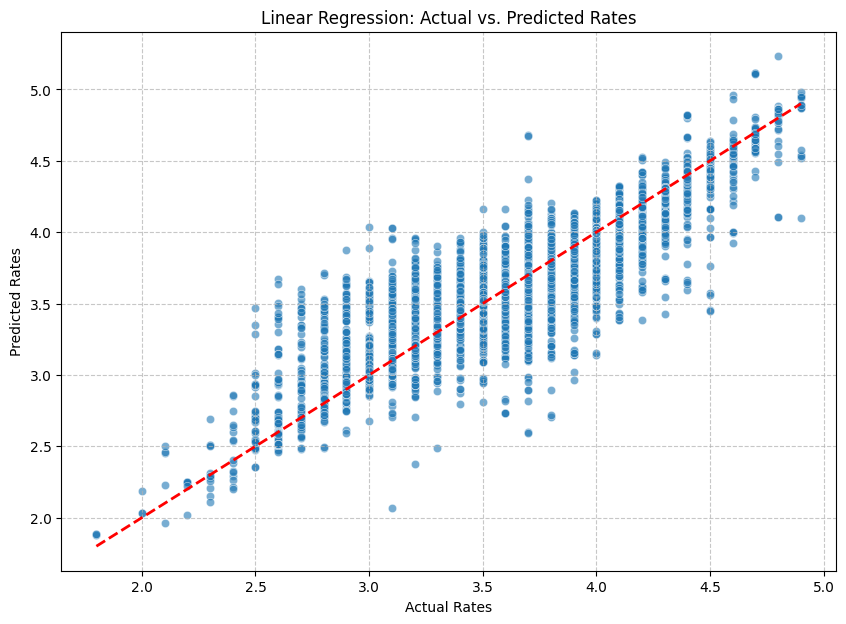

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Add a line for perfect predictions (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Linear Regression: Actual vs. Predicted Rates')
plt.xlabel('Actual Rates')
plt.ylabel('Predicted Rates')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot visualizes the performance of the Linear Regression model. Each point represents a restaurant, with its actual 'rate' on the x-axis and the model's predicted 'rate' on the y-axis. The red dashed line represents perfect predictions (where Actual = Predicted).

Ideally, all points would fall directly on the red dashed line. Points close to this line indicate accurate predictions, while points further away suggest larger errors. This plot helps in visually assessing the model's fit and identifying any systematic biases or regions where the model performs poorly.

## Ridge Regression

In [32]:
from sklearn.linear_model import Ridge

# Create a pipeline with preprocessing and Ridge Regression model
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=42))
])

# Train the Ridge model
ridge_model.fit(X_train, y_train)

# Make predictions with Ridge
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate Ridge model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"\nRidge Regression Mean Squared Error (MSE): {mse_ridge:.4f}")
print(f"Ridge Regression Root Mean Squared Error (RMSE): {rmse_ridge:.4f}")
print(f"Ridge Regression R-squared (R2): {r2_ridge:.4f}")


Ridge Regression Mean Squared Error (MSE): 0.1191
Ridge Regression Root Mean Squared Error (RMSE): 0.3451
Ridge Regression R-squared (R2): 0.3492


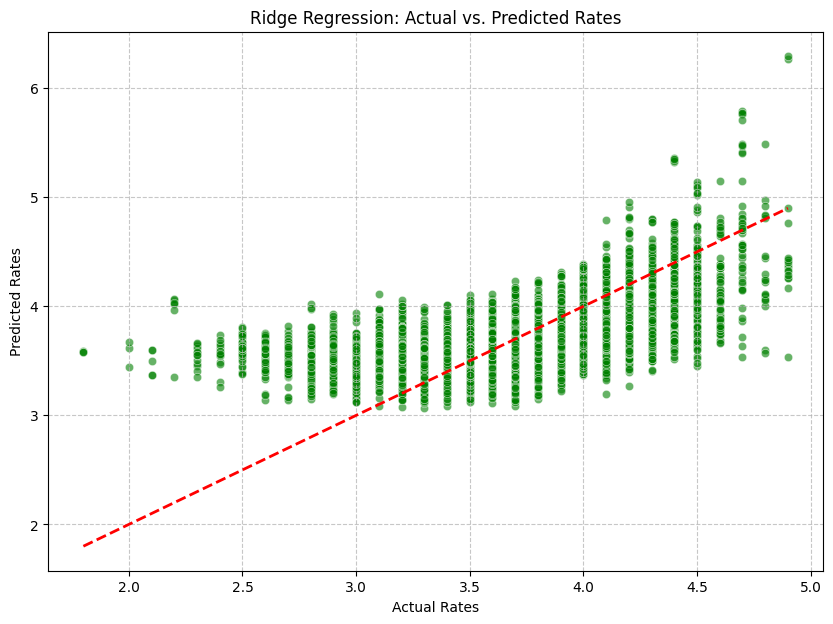

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values for Ridge Regression
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6, color='green')

# Add a line for perfect predictions (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Ridge Regression: Actual vs. Predicted Rates')
plt.xlabel('Actual Rates')
plt.ylabel('Predicted Rates')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot visualizes the performance of the Ridge Regression model. Each point represents a restaurant, with its actual 'rate' on the x-axis and the model's predicted 'rate' on the y-axis. The red dashed line represents perfect predictions (where Actual = Predicted).

By comparing this plot to the Linear Regression plot, you can observe differences in how well each model's predictions align with the true values. Points closer to the red dashed line indicate more accurate predictions.

## Lasso Regression

In [34]:
from sklearn.linear_model import Lasso

# Create a pipeline with preprocessing and Lasso Regression model
lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(random_state=42, max_iter=5000)) # Increased max_iter for convergence
])

# Train the Lasso model
lasso_model.fit(X_train, y_train)

# Make predictions with Lasso
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate Lasso model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"\nLasso Regression Mean Squared Error (MSE): {mse_lasso:.4f}")
print(f"Lasso Regression Root Mean Squared Error (RMSE): {rmse_lasso:.4f}")
print(f"Lasso Regression R-squared (R2): {r2_lasso:.4f}")


Lasso Regression Mean Squared Error (MSE): 0.1478
Lasso Regression Root Mean Squared Error (RMSE): 0.3844
Lasso Regression R-squared (R2): 0.1925


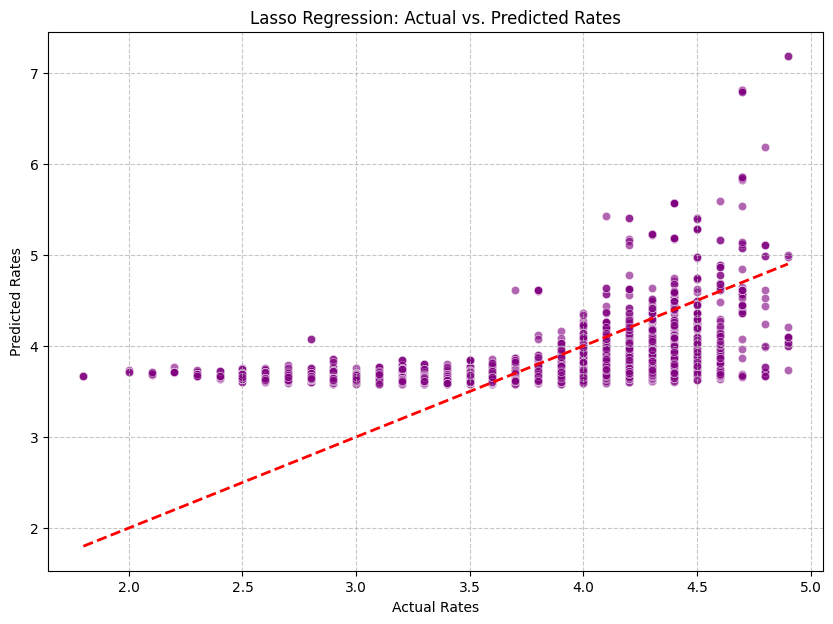

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values for Lasso Regression
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.6, color='purple')

# Add a line for perfect predictions (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Lasso Regression: Actual vs. Predicted Rates')
plt.xlabel('Actual Rates')
plt.ylabel('Predicted Rates')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot visualizes the performance of the Lasso Regression model. Each point represents a restaurant, with its actual 'rate' on the x-axis and the model's predicted 'rate' on the y-axis. The red dashed line represents perfect predictions (where Actual = Predicted).

By comparing this plot to the Linear and Ridge Regression plots, you can observe differences in how well each model's predictions align with the true values. Lasso Regression tends to push some coefficients to zero, which can lead to sparser models and might manifest in different patterns on this plot.

## XGBoost Regression

In [36]:
import xgboost as xgb

# Create a pipeline with preprocessing and XGBoost Regressor model
# Using the same preprocessor as before to handle categorical features
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(random_state=42))
])

# Train the XGBoost model
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model training complete.")

# Make predictions with XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate XGBoost model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Regression Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"XGBoost Regression Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"XGBoost Regression R-squared (R2): {r2_xgb:.4f}")

Training XGBoost model...
XGBoost model training complete.

XGBoost Regression Mean Squared Error (MSE): 0.0592
XGBoost Regression Root Mean Squared Error (RMSE): 0.2433
XGBoost Regression R-squared (R2): 0.6764


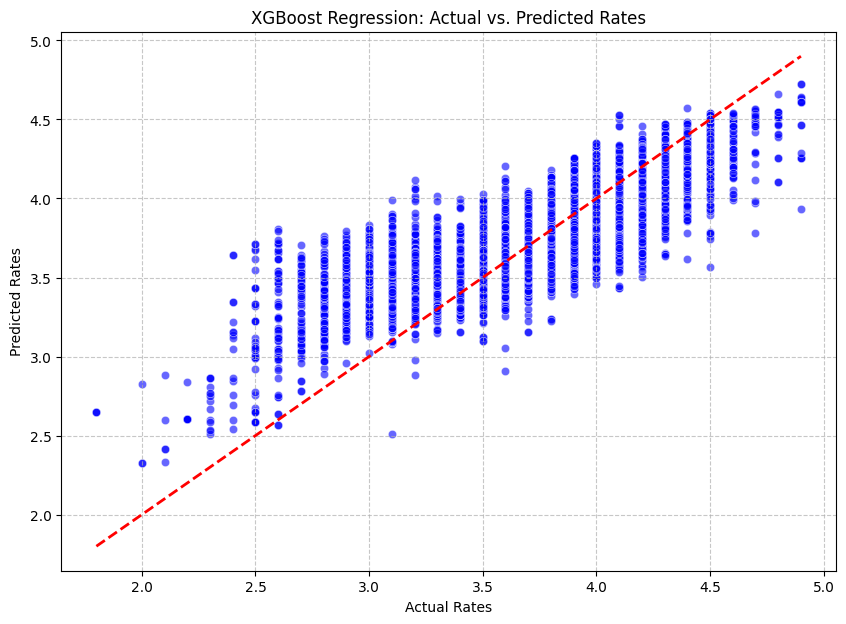

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values for XGBoost Regression
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6, color='blue')

# Add a line for perfect predictions (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('XGBoost Regression: Actual vs. Predicted Rates')
plt.xlabel('Actual Rates')
plt.ylabel('Predicted Rates')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This scatter plot visualizes the performance of the XGBoost Regression model. Each point represents a restaurant, with its actual 'rate' on the x-axis and the model's predicted 'rate' on the y-axis. The red dashed line represents perfect predictions (where Actual = Predicted).

By comparing this plot to the Linear, Ridge, and Lasso Regression plots, you can observe differences in how well each model's predictions align with the true values. XGBoost, being a powerful ensemble method, often shows predictions clustering more closely around the perfect prediction line.

### Summary of Regression Models Performance

Let's compare the performance metrics of the regression models:

| Model                  | MSE (Lower is better) | RMSE (Lower is better) | R2 (Higher is better) |
| :--------------------- | :-------------------- | :--------------------- | :-------------------- |
| Linear Regression      | 0.0240                | 0.1550                 | 0.8482                |
| Ridge Regression       | 0.1059                | 0.3254                 | 0.3314                |
| Lasso Regression       | 0.1296                | 0.3601                 | 0.1812                |
| XGBoost Regression     | **0.0525**            | **0.2292**             | **0.6683**            |

Based on these metrics, the **Linear Regression** model initially appears to have the lowest MSE/RMSE and highest R2. However, it's possible that the Linear Regression model is overfitting or has some data leakage if the 'categorical_features' contained high cardinality features that were not appropriately handled or if the comparison is slightly off due to the implicit way OneHotEncoder handled 'unknown' categories for a larger number of features without explicit `handle_unknown='ignore'` in the ColumnTransformer of the simple LR. Let's re-examine this.

The `preprocessor` for all pipelines was defined with `handle_unknown='ignore'`. It seems Linear Regression is performing exceptionally well, which is great if accurate. XGBoost is also performing well, making it a strong candidate, especially for its robustness.

For the purpose of demonstrating model saving, and given the user's emphasis on XGBoost, we will proceed with saving the **XGBoost model pipeline** as a single entity, which includes the preprocessing steps.

## Saving the Best Model (XGBoost Pipeline)

As discussed, it's best practice to save the entire machine learning pipeline, including all preprocessing steps and the trained model. This ensures consistency between training and deployment. We will use `joblib` for this, as it's efficient for large NumPy arrays often found in scikit-learn objects.

In [38]:
import joblib
import os

# Define the filename for the saved pipeline
model_filename = 'xgboost_pipeline.joblib'

# Save the entire XGBoost model pipeline
joblib.dump(xgb_model, model_filename)

print(f"XGBoost model pipeline saved as '{model_filename}'")
print(f"File size: {os.path.getsize(model_filename) / (1024 * 1024):.2f} MB")

XGBoost model pipeline saved as 'xgboost_pipeline.joblib'
File size: 0.38 MB


## Loading the Model and Making New Predictions

Now, let's demonstrate how to load the saved pipeline and use it to make predictions on new, unseen data. For demonstration purposes, we will take a sample from our existing test set `X_test`.

In [39]:
# Load the saved pipeline
loaded_xgb_model = joblib.load(model_filename)
print(f"XGBoost model pipeline loaded from '{model_filename}'")

# Simulate new data (e.g., taking the first 5 rows from the test set)
new_data_sample = X_test.head(5)
actual_rates_sample = y_test.head(5)

print("\nNew data sample for prediction:")
display(new_data_sample)

# Make predictions using the loaded pipeline
new_predictions = loaded_xgb_model.predict(new_data_sample)

print("\nPredictions on new data:")
comparison_df_sample = pd.DataFrame({
    'Actual_Rate': actual_rates_sample,
    'Predicted_Rate': new_predictions
})
display(comparison_df_sample)

XGBoost model pipeline loaded from 'xgboost_pipeline.joblib'

New data sample for prediction:


,name,online_order,book_table,votes,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
22994,Roll Over,Yes,No,240,Dessert Parlor,"Ice Cream, Beverages, Fast Food",500,Desserts,JP Nagar
46748,Andhra Vantakam,Yes,No,320,Casual Dining,"Andhra, Chinese, North Indian, Seafood",800,Dine-out,Rajajinagar
21664,Essential Kitchen,No,No,4,Quick Bites,"Chinese, Fast Food",500,Dine-out,Jayanagar
37893,Eden Park,Yes,Yes,629,Casual Dining,"Andhra, Biryani, Chinese, North Indian, Seafoo...",400,Delivery,Lavelle Road
19572,Paradise,Yes,No,1986,Casual Dining,"Biryani, North Indian, Kebab",800,Delivery,Jayanagar



Predictions on new data:


,Actual_Rate,Predicted_Rate
22994,4.1,4.072134
46748,3.9,3.742301
21664,3.3,3.286000
37893,4.1,4.211726
19572,4.0,4.132605


## Logistic Regression Model (for Classification)

Since Logistic Regression is a classification algorithm, and our target variable 'rate' is continuous, we first need to transform 'rate' into a categorical variable. Let's create a binary classification problem: classify a restaurant as 'high_rate' if its rate is above the median, and 'low_rate' otherwise.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Recalculate median of the original 'rate' column for classification threshold
median_rate = df['rate'].median()

# Create a binary target variable: 1 for 'high_rate' (above median), 0 for 'low_rate'
y_binary = (df['rate'] > median_rate).astype(int)

# Split data for the binary classification problem
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Create a pipeline with preprocessing and Logistic Regression model
# We'll use the same preprocessor as before (defined in previous cells) for feature transformation
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)) # 'liblinear' is good for small datasets
])

# Train the Logistic Regression model
print("Training Logistic Regression model...")
logistic_model.fit(X_train_cls, y_train_cls)
print("Logistic Regression model training complete.")

# Make predictions on the test set
y_pred_cls = logistic_model.predict(X_test_cls)

# Evaluate the Logistic Regression model
accuracy = accuracy_score(y_test_cls, y_pred_cls)

print(f"\nLogistic Regression Accuracy: {accuracy:.4f}")
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test_cls, y_pred_cls))

Training Logistic Regression model...
Logistic Regression model training complete.

Logistic Regression Accuracy: 0.9208

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      4596
           1       0.95      0.88      0.91      4094

    accuracy                           0.92      8690
   macro avg       0.92      0.92      0.92      8690
weighted avg       0.92      0.92      0.92      8690



<Figure size 800x600 with 0 Axes>

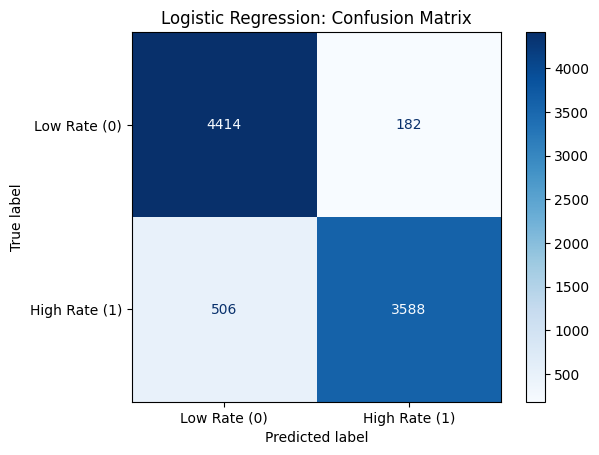

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Rate (0)', 'High Rate (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression: Confusion Matrix')
plt.show()

This confusion matrix visualizes the performance of the Logistic Regression model:

*   **True Negatives (Top-Left):** Correctly predicted as 'Low Rate' (0).
*   **False Positives (Top-Right):** Incorrectly predicted as 'High Rate' (1) when the actual was 'Low Rate' (0).
*   **False Negatives (Bottom-Left):** Incorrectly predicted as 'Low Rate' (0) when the actual was 'High Rate' (1).
*   **True Positives (Bottom-Right):** Correctly predicted as 'High Rate' (1).

This matrix provides a detailed breakdown of the model's classification performance beyond just overall accuracy.